In [154]:
import pandas as pd
import math
# Cell 1
df = pd.read_csv("20Sproteasome.csv", sep=";")
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head(5)

,molecule_chembl_id,molecule_name,molecule_max_phase,molecular_weight,#ro5_violations,alogp,compound_key,smiles,standard_type,standard_relation,...,document_chembl_id,source_id,source_description,document_journal,document_year,cell_chembl_id,properties,action_type,standard_text_value,value
0,CHEMBL374495,CINNABARAMIDE D,NaN,369.46,0.0,0.97,4,CCCCCC(O)[C@H]1C(=O)N[C@](C(=O)O)([C@@H](O)[C@@H]2C=CCCC2)[C@@]1(C)O,IC50,'=',...,CHEMBL1141377,1,Scientific Literature,J Nat Prod,2007,NaN,NaN,NaN,NaN,100.0
1,CHEMBL362804,NaN,NaN,609.72,1.0,3.89,TP-109,COc1ccc(C[C@H](NC(=O)Cc2cccc3ccccc23)C(=O)N[C@H](C(=O)NC(C=O)Cc2ccc(O)cc2)C(C)C)cc1,IC50,'=',...,CHEMBL1143504,1,Scientific Literature,Bioorg Med Chem Lett,2005,CHEMBL3307654,NaN,NaN,NaN,31.0
2,CHEMBL2371767,NaN,NaN,540.66,1.0,1.36,TP-111,COc1ccc(C[C@@H](C=O)NC(=O)[C@@H](NC(=O)[C@H](Cc2ccc(OC)cc2)NC(=O)CN(C)C)C(C)C)cc1,IC50,'=',...,CHEMBL1143504,1,Scientific Literature,Bioorg Med Chem Lett,2005,CHEMBL3307654,NaN,NaN,NaN,7.8
3,CHEMBL360654,NaN,NaN,609.72,1.0,3.89,TP-108,COc1ccc(CC(C=O)NC(=O)[C@@H](NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)Cc2cccc3ccccc23)C(C)C)cc1,IC50,'=',...,CHEMBL1143504,1,Scientific Literature,Bioorg Med Chem Lett,2005,CHEMBL3307654,NaN,NaN,NaN,38.0
4,CHEMBL361462,NaN,NaN,623.75,1.0,4.19,TP-110,COc1ccc(CC(C=O)NC(=O)[C@@H](NC(=O)[C@H](Cc2ccc(OC)cc2)NC(=O)Cc2cccc3ccccc23)C(C)C)cc1,IC50,'>',...,CHEMBL1143504,1,Scientific Literature,Bioorg Med Chem Lett,2005,CHEMBL3307654,NaN,NaN,NaN,100.0


In [155]:
df.shape

(860, 48)

In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   molecule_chembl_id          860 non-null    str    
 1   molecule_name               94 non-null     str    
 2   molecule_max_phase          67 non-null     float64
 3   molecular_weight            858 non-null    float64
 4   #ro5_violations             677 non-null    float64
 5   alogp                       677 non-null    float64
 6   compound_key                860 non-null    str    
 7   smiles                      858 non-null    str    
 8   standard_type               860 non-null    str    
 9   standard_relation           730 non-null    str    
 10  standard_value              730 non-null    float64
 11  standard_units              630 non-null    str    
 12  pchembl_value               273 non-null    float64
 13  data_validity_comment       1 non-null      st

In [157]:
df["standard_type"].value_counts()

standard_type
IC50               318
Activity           189
FC                 137
EC200               91
Inhibition          60
EC50                32
AC200               12
Drug metabolism     10
CD                   6
Ki                   3
Ratio IC50           2
Name: count, dtype: int64

In [158]:
def pic50(ic50_nm):
    """Convert IC50 in nM to pIC50."""
    if ic50_nm is None or ic50_nm <= 0: return float("nan")
    if math.isnan(ic50_nm): return float("nan")
    return -math.log10(ic50_nm * 1e-9)

df = df[df["standard_type"] == "IC50"].copy()
df.loc[df.standard_units=="uM", "standard_value"] *= 1000   # uM → nM
df.dropna(subset=["standard_value"], inplace=True)
df["pIC50"] = df["standard_value"].apply(pic50)
df["active"] = df["pIC50"] >= 7.0
print(df["active"].value_counts())

active
False    172
True     138
Name: count, dtype: int64


In [159]:
df["potent"] = df["pIC50"] >= 9.0

In [164]:
from rdkit import Chem
from rdkit.Chem import QED

# 1. Filter for only the rows where 'potent' (or 'active') is True
# (Assuming your boolean column is named 'potent')
potent_df = df[df["potent"] == True].copy()

# 2. Convert SMILES strings to RDKit Mol objects
# We use a lambda to safely convert and handle any missing/corrupt SMILES
potent_df["mol"] = potent_df["smiles"].apply(
    lambda s: Chem.MolFromSmiles(s) if isinstance(s, str) else None
)

# Drop any rows where SMILES conversion failed (None values)
potent_df = potent_df.dropna(subset=["mol"])

# 3. Now calculate QED on the Mol objects
potent_qed = [QED.qed(m) for m in potent_df["mol"]]

# Optional: Add it back to your filtered dataframe
potent_df["QED"] = potent_qed
# Show the first 10 QED scores calculated
print(potent_qed[:10])

[0.425673795116166, 0.16452818844743317, 0.17631107110893077]


In [ ]:
import pandas as pd

# Remove the column width limit completely
pd.set_option('display.max_colwidth', None)

# Now run your code again!
df.loc[df["potent"], "smiles"]

76                                   CCCCCC[C@H]1C(=O)N[C@@]2([C@@H](O)[C@@H]3C=CCCC3)C(=O)O[C@@]12C
259    CC(C)(C)CNC(=O)C[C@H](NC(=O)N1CCC(C(=O)Nc2nccs2)CC1)C(=O)N[C@@H](CCc1ccccc1)C(=O)NCc1ccccc1Cl
490          CCCCCC[C@H]1C(=O)N[C@](C(=O)SC[C@H](NC(C)=O)C(=O)OC)([C@@H](O)[C@@H]2C=CCCC2)[C@@]1(C)O
Name: smiles, dtype: str

- Cinnabaramide A
- a complex, peptidomimetic inhibitor compound. It is most prominently recognized as part of a class of inhibitors of the Hepatitis C virus (HCV) NS3 protease
- Cinnabaramide G



<Axes: >

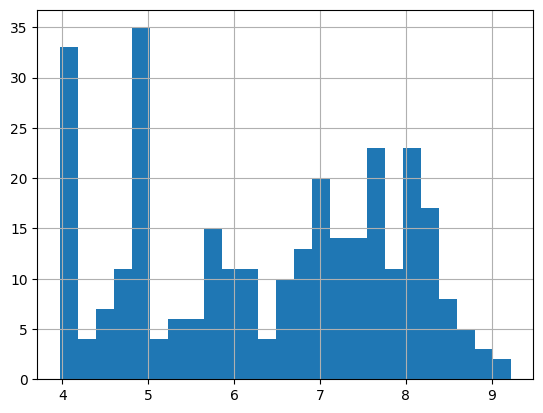

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math
df["pIC50"].hist(bins=25)

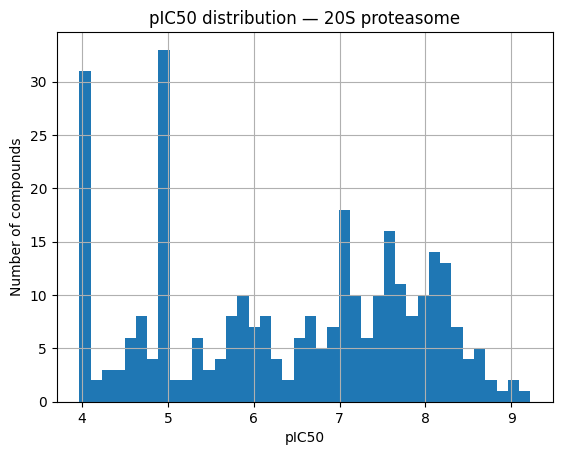

In [ ]:
df = df[df["pIC50"] <= 12]

df["pIC50"].hist(bins=40)
plt.xlabel("pIC50")
plt.ylabel("Number of compounds")
plt.title("pIC50 distribution — 20S proteasome")
plt.show()

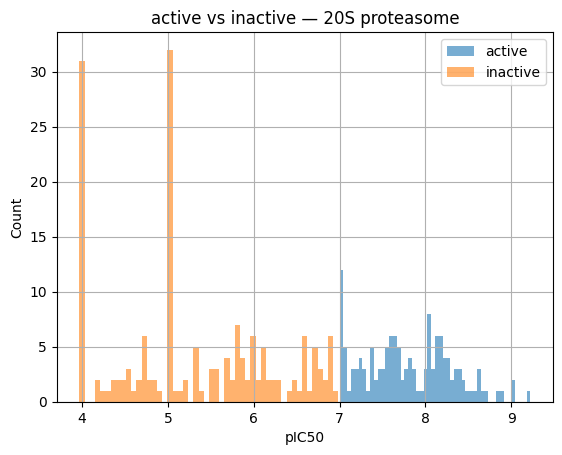

In [ ]:
df[df["active"] == True]["pIC50"].hist(bins=50, alpha=0.6, label="active")
df[df["active"] == False]["pIC50"].hist(bins=50, alpha=0.6, label="inactive")
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("active vs inactive — 20S proteasome")
plt.legend()
plt.show()

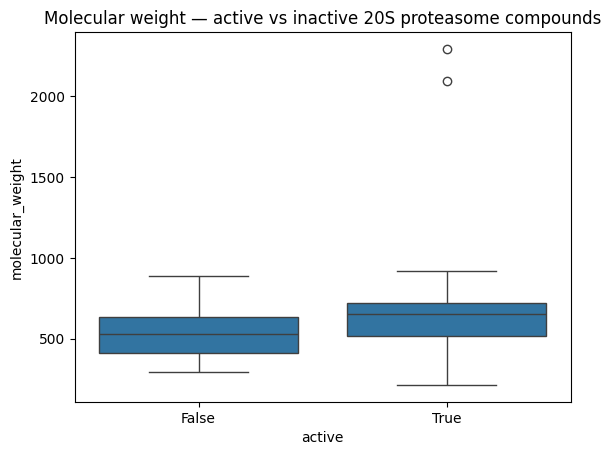

In [ ]:
import seaborn as sns

df["molecular_weight"] = pd.to_numeric(df["molecular_weight"], errors="coerce")

sns.boxplot(data=df, x="active", y="molecular_weight")
plt.title("Molecular weight — active vs inactive 20S proteasome compounds")
plt.show()

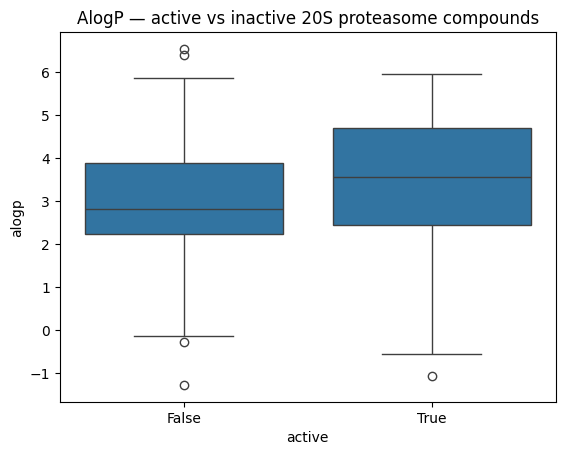

In [ ]:
df["alogp"] = pd.to_numeric(df["alogp"], errors="coerce")
sns.boxplot(data=df, x="active", y="alogp")
plt.title("AlogP — active vs inactive 20S proteasome compounds")
plt.show()

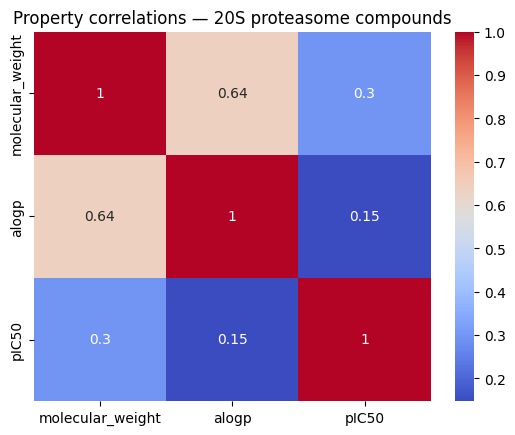

In [ ]:
cols = ["molecular_weight", "alogp", "pIC50"]
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Property correlations — 20S proteasome compounds")
plt.show()

Top 6 core scaffolds by frequency:
Scaffold_SMILES
c1ccccc1                                                                                 10
O=C(CNC(=O)N1CCC(C(=O)Nc2ccccc2)CC1)N[C@@H](CCc1ccccc1)C(=O)N[C@@H]1CCCc2ccccc21          7
O=C(CNC(=O)c1cccc(Cc2n[nH]c(=O)c3ccccc23)c1)NCB1OC2[C@H]3C[C@@H](C[C@H]2O1)C3             6
O=C(CNC(=O)c1ccon1)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)C1CO1                                    5
O=C(CNC(=O)CNC(=O)c1ccon1)NCC(=O)C1CO1                                                    5
O=C(CNC(=O)[C@@H](C[C@H](Cc1ccccc1)NC(=O)CNC(=O)Cc1cccc2ccccc12)NCc1ccccc1)NCc1ccccc1     4
Name: count, dtype: int64


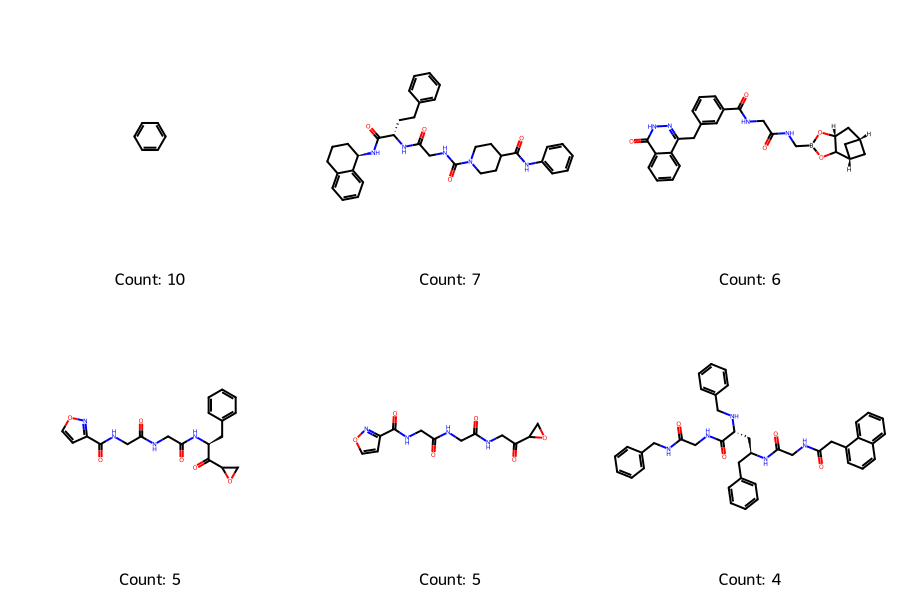

In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools

actives = df[df["active"] == True].copy()
actives = actives[actives["smiles"].apply(lambda x: isinstance(x, str))].copy()
PandasTools.AddMoleculeColumnToFrame(actives, smilesCol="smiles", molCol="ROMol")

actives['Scaffold'] = actives['ROMol'].apply(lambda x: MurckoScaffold.GetScaffoldForMol(x) if x else None)

actives['Scaffold_SMILES'] = actives['Scaffold'].apply(lambda x: Chem.MolToSmiles(x) if x else None)

top_scaffolds = actives['Scaffold_SMILES'].value_counts().head(6)

print("Top 6 core scaffolds by frequency:")
print(top_scaffolds)

scaffold_mols = [Chem.MolFromSmiles(smi) for smi in top_scaffolds.index if type(smi) == str]
legends = [f"Count: {count}" for count in top_scaffolds.values]

Draw.MolsToGridImage(scaffold_mols, molsPerRow=3, subImgSize=(300, 300), legends=legends)